# Required package

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
from statsmodels.tsa.arima_process import ArmaProcess
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [37]:
from sklearn.metrics import mean_squared_error

# Exercise 5.6.1)

## 1

In [3]:
np.random.seed(42)
ma2 = np.array([1, 0, 0])
ar2 = np.array([1, -0.33, -0.50]) # negative is positive
AR2 = ArmaProcess(ar2, ma2).generate_sample(nsample=1000)

In [4]:
AR2

array([ 4.96714153e-01,  2.56513693e-02,  9.04510566e-01,  1.83434403e+00,
        8.23435438e-01,  9.54768752e-01,  2.30600422e+00,  2.00580050e+00,
        1.34544189e+00,  1.98945612e+00,  8.65823770e-01,  8.14720149e-01,
        9.43731806e-01, -1.19448867e+00, -1.64723319e+00, -1.70311882e+00,
       -2.39847693e+00, -1.32880946e+00, -2.54576966e+00, -2.91681242e+00,
       -7.69784161e-01, -1.93821128e+00, -9.56973600e-01, -2.70965512e+00,
       -1.91705571e+00, -1.87653335e+00, -2.72877744e+00, -1.46306521e+00,
       -2.44783893e+00, -1.83101320e+00, -2.42986043e+00,  1.34917639e-01,
       -1.18390462e+00, -1.38094063e+00, -2.25117808e-01, -1.98560284e+00,
       -5.58944247e-01, -3.13692315e+00, -2.64284281e+00, -2.24373847e+00,
       -1.32338852e+00, -1.38721916e+00, -1.23512487e+00, -1.40230448e+00,
       -2.55884490e+00, -2.26541527e+00, -2.48764826e+00, -8.96509334e-01,
       -1.19605392e+00, -2.60599262e+00, -1.13392055e+00, -2.06227237e+00,
       -1.92443216e+00, -

## 2

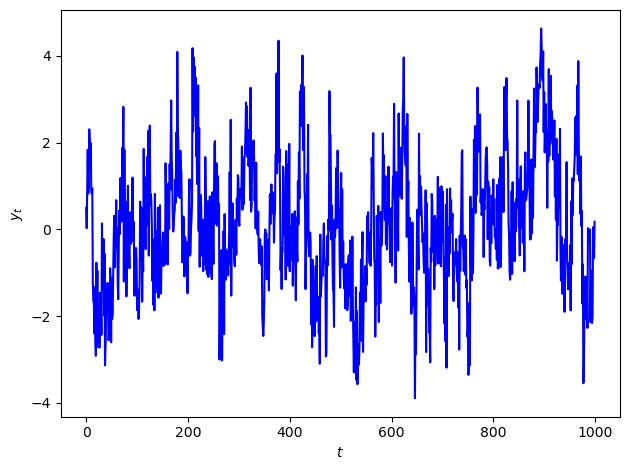

In [6]:
fig, ax = plt.subplots()
ax.plot(AR2, 'b-')
ax.set_xlabel('$t$')
ax.set_ylabel('$y_t$')
plt.tight_layout()
plt.show()

## 3

In [8]:
adfuller(AR2)

(np.float64(-7.566606021416919),
 np.float64(2.914516129376086e-11),
 1,
 998,
 {'1%': np.float64(-3.4369193380671),
  '5%': np.float64(-2.864440383452517),
  '10%': np.float64(-2.56831430323573)},
 np.float64(2738.246771318533))

## 4

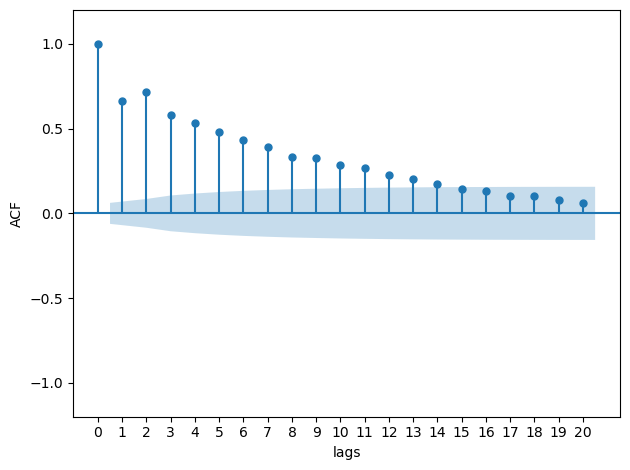

In [19]:
fig, ax = plt.subplots()
plot_acf(AR2, lags=20, ax=ax)
ax.set_xlabel('lags')
ax.set_ylabel('ACF')
ax.set_title('')
ax.set_xticks(np.arange(0, 21, 1))
ax.set_ylim([-1.2, 1.2])
plt.tight_layout()
plt.show()

## 5

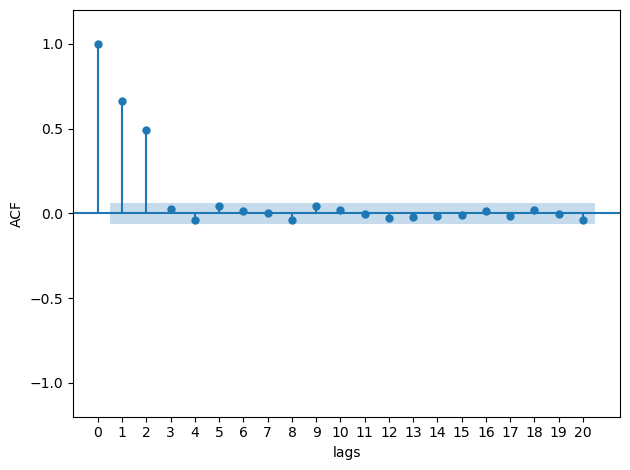

In [20]:
fig, ax = plt.subplots()
plot_pacf(AR2, lags=20, ax=ax)
ax.set_xlabel('lags')
ax.set_ylabel('ACF')
ax.set_title('')
ax.set_xticks(np.arange(0, 21, 1))
ax.set_ylim([-1.2, 1.2])
plt.tight_layout()
plt.show()

## 6

In [21]:
train = AR2[:800]
test = AR2[800:]

## 7

In [24]:
def rolling_forecast(df: pd.DataFrame, column: str, train_len: int, horizon: int, method: str, window: int = 2) -> list:
    """
    Compute rolling forecast for a Time Series using last value, mean or MA(2) model.

    It takes a DataFrame object with train and test data points.

    Args:
    -----
        df (pd.DataFrame): 
            DataFrame with all data points
        column (str):
            column to be forecast
        train_len (int): 
            number of data points used to fit the model 
        horizon (int):
            length of test set
        window (int):
            number of timesteps predicted at time
        method (str):
            specifies what model to use. It must be "last", "mean", "AR"

    Returns:
    --------
        list: predicted values
    """

    total_len = train_len + horizon

    if method == 'mean':
        pred_mean = []
    
        for i in range(train_len, total_len, window):
            mean = np.mean(df.loc[:, column].iloc[:i].values)
            pred_mean.extend(mean for _ in range(window))
            
        return pred_mean

    if method == 'last':
        pred_last_value = []
        
        for i in range(train_len, total_len, window):
            last_value = df.loc[:, column].iloc[:i].iloc[-1]
            pred_last_value.extend(last_value for _ in range(window))
            
        return pred_last_value

    if method == 'AR':
        pred_ar = []
        for i in range(train_len, total_len, window):
            model = SARIMAX(df.loc[:, column].iloc[:i], order=(2,0,0))
            res = model.fit(disp=False)
            predictions = res.get_prediction(0, i + window - 1)
            oos_pred = predictions.predicted_mean.iloc[-window:]
            pred_ar.extend(oos_pred)
            
        return pred_ar

In [25]:
df = pd.DataFrame({'ar2': AR2})

In [26]:
?rolling_forecast

Signature:
rolling_forecast(
    df: pandas.DataFrame,
    column: str,
    train_len: int,
    horizon: int,
    method: str,
    window: int = 2,
) -> list
Docstring:
Compute rolling forecast for a Time Series using last value, mean or MA(2) model.

It takes a DataFrame object with train and test data points.

Args:
-----
    df (pd.DataFrame): 
        DataFrame with all data points
    column (str):
        column to be forecast
    train_len (int): 
        number of data points used to fit the model 
    horizon (int):
        length of test set
    window (int):
        number of timesteps predicted at time
    method (str):
        specifies what model to use. It must be "last", "mean", "AR"

Returns:
--------
    list: predicted values
File:      /tmp/ipykernel_7356/3861210297.py
Type:      function

In [31]:
df_pred = pd.DataFrame({
    'actual': test,
    'last': rolling_forecast(df, 'ar2', train_len=800, horizon=200, window=2, method='last'),
    'mean': rolling_forecast(df, 'ar2', train_len=800, horizon=200, window=2, method='mean'),
    'AR': rolling_forecast(df, 'ar2', train_len=800, horizon=200, window=2, method='AR'),
}, index=df[800:].index)

## 8

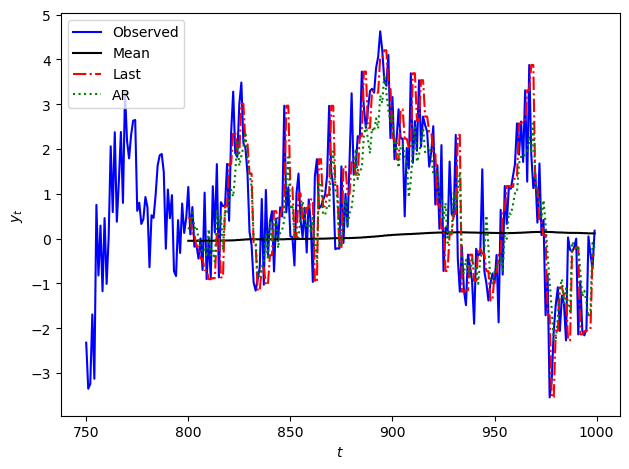

In [36]:
fig, ax = plt.subplots()
ax.plot(df[750:], 'b-', label='Observed')
ax.plot(df_pred['mean'], 'k-', label='Mean')
ax.plot(df_pred['last'], 'r-.', label='Last')
ax.plot(df_pred['AR'], 'g:', label='AR')
ax.set_xlabel('$t$')
ax.set_ylabel('$y_t$')
ax.legend(loc='upper left')
plt.tight_layout()
plt.show()

## 9

In [39]:
mse = pd.Series({
    'mean': mean_squared_error(df_pred['actual'], df_pred['mean']),
    'last': mean_squared_error(df_pred['actual'], df_pred['last']),
    'AR(2)': mean_squared_error(df_pred['actual'], df_pred['AR'])
})

In [40]:
mse

mean     3.088202
last     1.211152
AR(2)    0.969264
dtype: float64

## 10

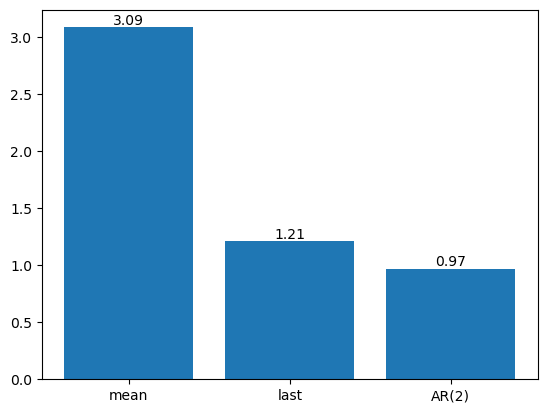

In [41]:
fig, ax = plt.subplots()
bars = ax.bar(mse.index, mse.values)
ax.bar_label(bars, fmt='%.2f')
plt.show()